<a href="https://colab.research.google.com/github/prabuddhayogi/ai-with-python/blob/CNN/CNN_celebA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Load Images From Folder and load Attributes excel file

In [17]:
import os
import numpy as np
import pandas as pd
from PIL import Image

image_folder = "/content/drive/MyDrive/AI-python/lecture38/image_folder"          # my folder with 2000 images
attribute_file = "/content/drive/MyDrive/AI-python/lecture38/list_attr_celeba.xlsx"

df = pd.read_excel(attribute_file)

# Convert CelebA labels (-1,1) → (0,1)
df = df.replace(-1,0)

df.iloc[:,1:] = df.iloc[:,1:].apply(pd.to_numeric, errors='coerce')


images = []
labels = []

for i in range(len(df)):

    img_name = df.iloc[i,0]
    img_path = os.path.join(image_folder,img_name)

    img = Image.open(img_path).convert("RGB")
    img = img.resize((64,64))

    img_array = np.array(img)/255.0

    images.append(img_array)
    labels.append(df.iloc[i,1:].values.astype("float32"))

X = np.array(images)
y = np.array(labels)

print(X.dtype, X.shape)  # float32, (2000, 64, 64, 3)
print(y.dtype, y.shape)


float64 (2000, 64, 64, 3)
float32 (2000, 40)


In [18]:
X = X.astype("float32")

Train/Test Split

In [19]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

CNN Model : Using sigmoid + binary_crossentropy instead of softmax. Since with softmax, had to train model for each attribute but with sigmoid, could do it with one training

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense
from tensorflow.keras.layers import GlobalAveragePooling2D

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    MaxPooling2D((2,2)),

    Conv2D(64,(3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(128,(3,3), activation='relu'),
    MaxPooling2D((2,2)),

    GlobalAveragePooling2D(),  # outputs 128 features
    Dense(128, activation='relu'),
    Dense(40, activation='sigmoid')
])

Compile Model

In [24]:
model.compile(

    optimizer='adam',

    loss='binary_crossentropy',   # multi-label classification

    metrics=['accuracy']
)

Train model

In [25]:
history = model.fit(
    X_train,
    y_train,

    epochs=10,

    batch_size=32,

    validation_split=0.1
)

Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 12s 227ms/step - accuracy: 0.0021 - loss: 0.4837 - val_accuracy: 0.0000e+00 - val_loss: 0.4414
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 177ms/step - accuracy: 0.0021 - loss: 0.4346 - val_accuracy: 0.0000e+00 - val_loss: 0.4351
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 10s 223ms/step - accuracy: 6.9444e-04 - loss: 0.4314 - val_accuracy: 0.0000e+00 - val_loss: 0.4320
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 10s 210ms/step - accuracy: 6.9444e-04 - loss: 0.4298 - val_accuracy: 0.0000e+00 - val_loss: 0.4302
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 10s 220ms/step - accuracy: 0.0021 - loss: 0.4276 - val_accuracy: 0.0000e+00 - val_loss: 0.4270
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 10s 225ms/step - accuracy: 6.9444e-04 - loss: 0.4264 - val_accuracy: 0.0000e+00 - val_loss: 0.4244
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 206ms/step - accuracy: 0.0000e+00 - loss: 0.4239 - val_accuracy: 0.0000e+00 - val_loss: 0.4244
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 194ms/step - a

In [26]:
prediction = model.predict(X_test[:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step


In [27]:
predicted_attributes = (prediction > 0.5).astype(int)

print(predicted_attributes)

[[0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0
  1 0 0 1]]


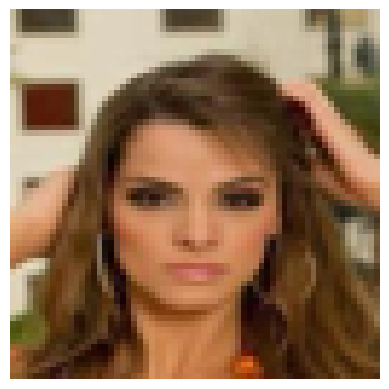

In [28]:
import matplotlib.pyplot as plt

plt.imshow(X_test[0])
plt.axis('off')
plt.show()

In [29]:
attribute_names = df.columns[1:]

In [35]:
image_path = "/content/drive/MyDrive/AI-python/lecture38/002020.jpg"

img = Image.open(image_path).convert("RGB")
img = img.resize((64,64))

img_array = np.array(img)/255.0
img_array = img_array.reshape(1,64,64,3)

In [36]:
prediction = model.predict(img_array)

predicted_attributes = (prediction > 0.5).astype(int)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


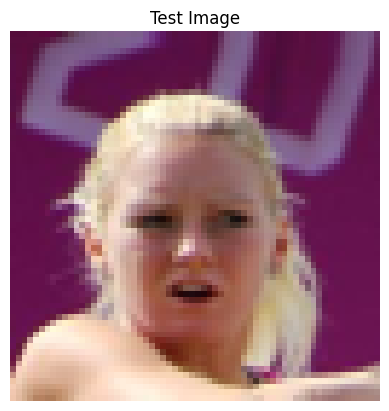

Predicted attributes:

Attractive
Mouth_Slightly_Open
No_Beard
Smiling
Young


In [37]:
plt.imshow(img)
plt.axis("off")
plt.title("Test Image")
plt.show()
print("Predicted attributes:\n")

for i,value in enumerate(predicted_attributes[0]):

    if value == 1:
        print(attribute_names[i])